Accuracy: 0.7962128043282236
Precision: 0.787719298245614
Recall: 0.8104693140794224
F1-score: 0.798932384341637

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       555
           1       0.79      0.81      0.80       554

    accuracy                           0.80      1109
   macro avg       0.80      0.80      0.80      1109
weighted avg       0.80      0.80      0.80      1109


Confusion Matrix:
[[434 121]
 [105 449]]

Bias (intercept): 5.0

Coeficientes:
                                              feature  coeficiente
21                               População total 2017   -20.008512
15  % de pessoas inscritas no Cadastro Único que r...    14.945539
17  % da população urbana residente em domicílios ...    -6.550352
6      Transferência per capita do Bolsa Família 2017     4.892272
2         IDEB anos finais do ensino fundamental 2017    -4.201268
3   % de alunos do ensino fundamental em escolas c... 

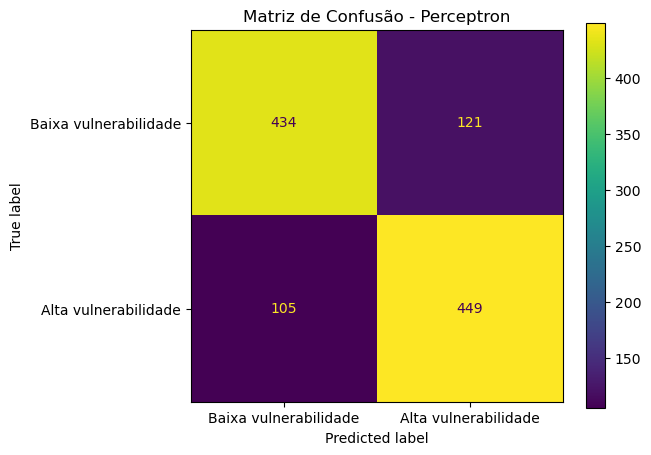

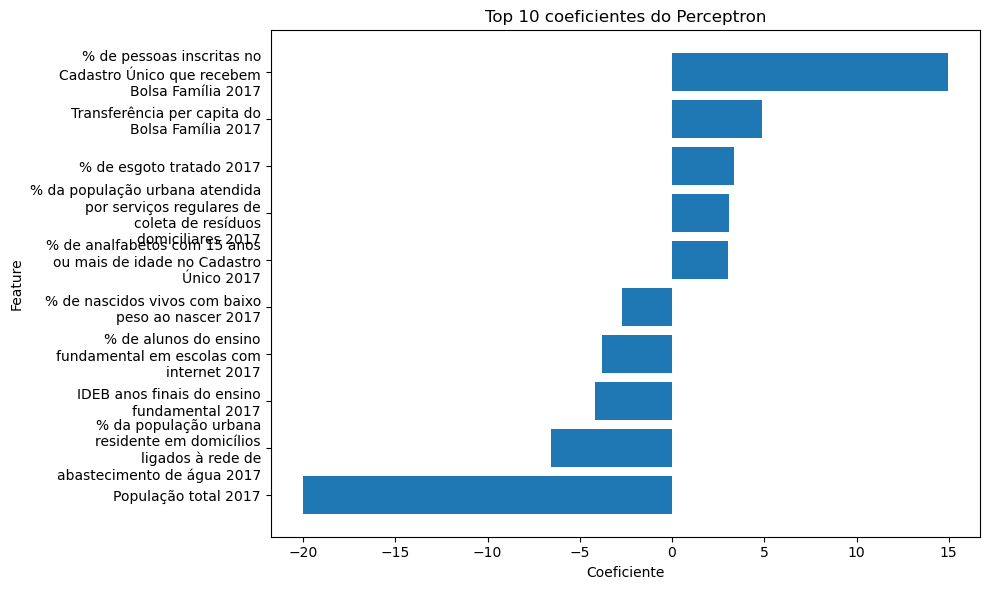

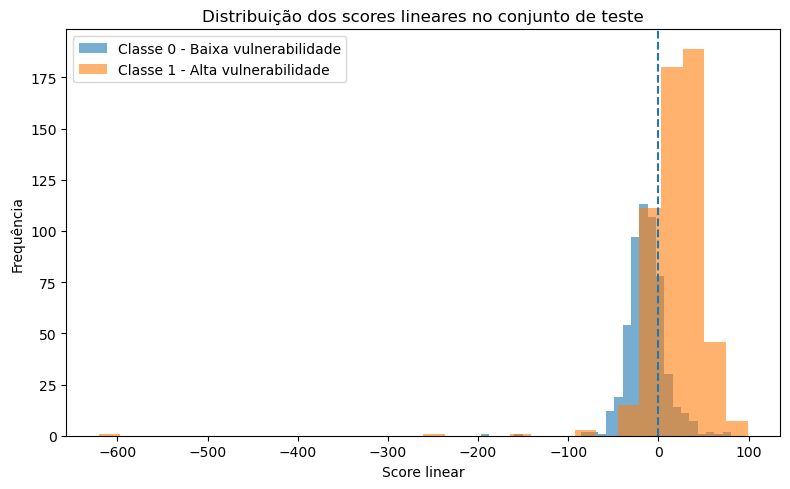

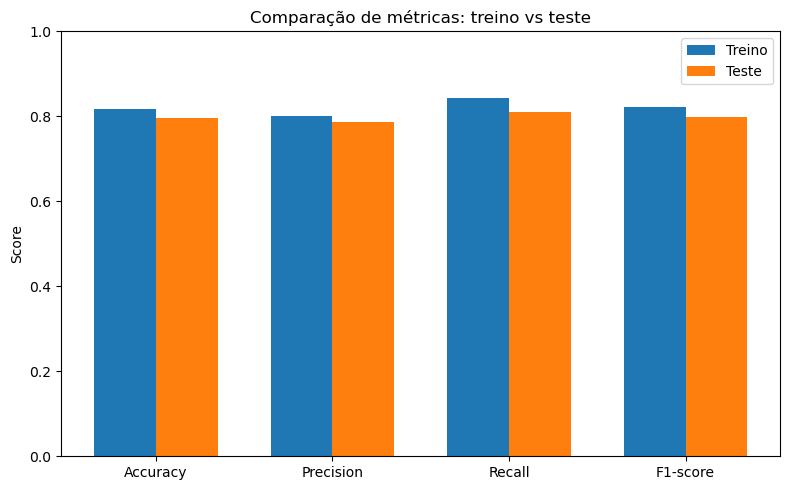

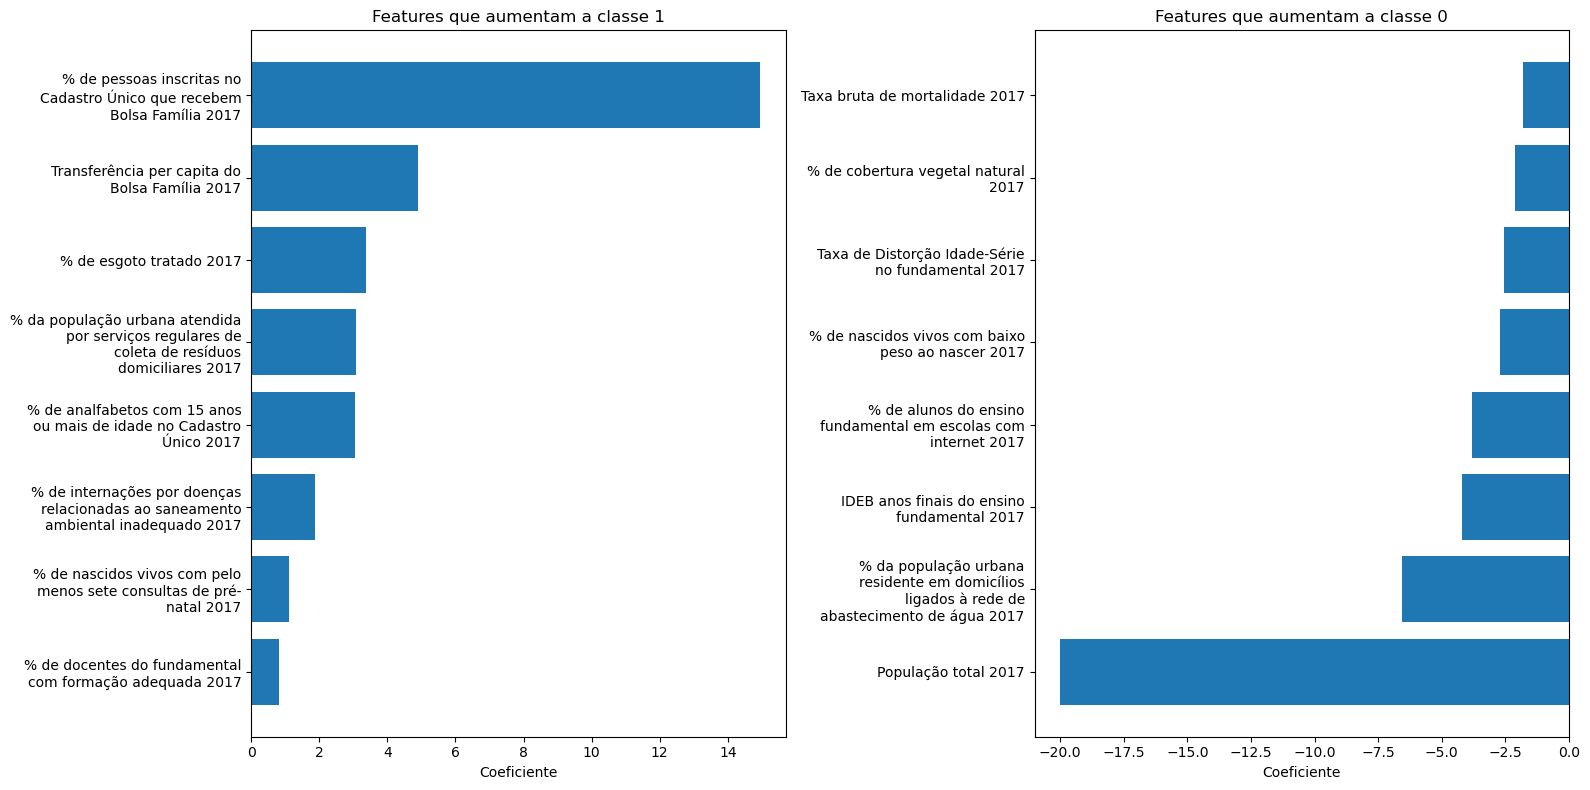

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

CSV_PATH = '../data/censo_municipal.csv'
ID_COL = "Territorialidades"
TARGET_SOURCE_COL = "% de extremamente pobres no Cadastro Único pós Bolsa Família 2017"
TEST_SIZE = 0.20
RANDOM_STATE = 42

def wrap_labels(labels, width=30):
    return [textwrap.fill(label, width) for label in labels]

df = pd.read_csv(CSV_PATH)

for col in df.columns:
    if col != ID_COL:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace("%", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .replace(["nan", "None", ""], np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[TARGET_SOURCE_COL]).copy()

municipios = df[ID_COL].copy()

threshold = df[TARGET_SOURCE_COL].median()
df["vulnerabilidade_alta"] = (df[TARGET_SOURCE_COL] > threshold).astype(int)

drop_cols = [ID_COL, TARGET_SOURCE_COL, "vulnerabilidade_alta"]

X = df.drop(columns=drop_cols).copy()
y = df["vulnerabilidade_alta"].copy()

X = X.select_dtypes(include=[np.number]).copy()

X_train, X_test, y_train, y_test, municipios_train, municipios_test = train_test_split(
    X,
    y,
    municipios,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("perceptron", Perceptron(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE))
])

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test)

print("\nConfusion Matrix:")
print(cm)

perceptron = model.named_steps["perceptron"]
coef = perceptron.coef_.ravel()
intercept = perceptron.intercept_[0]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coeficiente": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("\nBias (intercept):", intercept)

print("\nCoeficientes:")
print(coef_df[["feature", "coeficiente"]])

norm_w = np.linalg.norm(coef)
print("\nNorma do vetor de pesos:", norm_w)

decision_scores = model.decision_function(X_test)

scores_df = pd.DataFrame({
    "municipio": municipios_test.values,
    "score": decision_scores,
    "real": y_test.values,
    "pred": y_pred_test
})

print("\nExemplos de scores:")
print(scores_df.head())

train_acc = accuracy_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train, zero_division=0)

print("\nTreino Accuracy:", train_acc)
print("Treino F1:", train_f1)

gap = train_f1 - f1
print("\nGap F1 treino-teste:", gap)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Baixa vulnerabilidade", "Alta vulnerabilidade"])
disp.plot(ax=plt.gca(), values_format="d")
plt.title("Matriz de Confusão - Perceptron")
plt.grid(False)
plt.show()

top_coef_df = coef_df.head(10).sort_values("coeficiente")
plt.figure(figsize=(10, 6))
plt.barh(wrap_labels(top_coef_df["feature"]), top_coef_df["coeficiente"])
plt.title("Top 10 coeficientes do Perceptron")
plt.xlabel("Coeficiente")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(decision_scores[y_test == 0], bins=30, alpha=0.6, label="Classe 0 - Baixa vulnerabilidade")
plt.hist(decision_scores[y_test == 1], bins=30, alpha=0.6, label="Classe 1 - Alta vulnerabilidade")
plt.axvline(0, linestyle="--")
plt.title("Distribuição dos scores lineares no conjunto de teste")
plt.xlabel("Score linear")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
train_metrics = [
    accuracy_score(y_train, y_pred_train),
    precision_score(y_train, y_pred_train, zero_division=0),
    recall_score(y_train, y_pred_train, zero_division=0),
    f1_score(y_train, y_pred_train, zero_division=0)
]
test_metrics = [acc, prec, rec, f1]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, train_metrics, width, label="Treino")
plt.bar(x + width/2, test_metrics, width, label="Teste")
plt.xticks(x, metrics_names)
plt.ylim(0, 1)
plt.title("Comparação de métricas: treino vs teste")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

top_positive = coef_df.sort_values("coeficiente", ascending=False).head(8)
top_negative = coef_df.sort_values("coeficiente", ascending=True).head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(wrap_labels(top_positive["feature"][::-1]), top_positive["coeficiente"][::-1])
axes[0].set_title("Features que aumentam a classe 1")
axes[0].set_xlabel("Coeficiente")

axes[1].barh(wrap_labels(top_negative["feature"]), top_negative["coeficiente"])
axes[1].set_title("Features que aumentam a classe 0")
axes[1].set_xlabel("Coeficiente")

plt.tight_layout()
plt.show()